## KNN（K-Nearest Neighbors）

> 简单来说，K近邻（KNN）算法就是让与待预测元素距离最近（通常采用欧氏距离）的K个元素（邻居）来投票决定待预测元素的类别
>
> 为避免同票数的情况，通常将K值设为奇数
>
> KNN 的内部过程实际上只是将新输入的元素与原数据集的元素计算距离，.fit()阶段也只是把训练集保存好，并没有真正意义上的训练一说，因此是一种“惰性学习”算法，且相当依赖数据集的质量

问题：
本例中将以将以 scikit-learn 库中内置的鸢尾花数据集来进行训练，用数据集提供的4种属性及其数据来预测测试元素为3种鸢尾花（分别用 0, 1, 2 来编号）中的哪一种，是个典型的分类问题
> 数据集名为 iris ，可用 sklearn 的 load_iris 来导入

In [114]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

### 1.导入并观察数据集的结构

In [115]:
iris = load_iris()
print(iris['DESCR'])
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


### 2.划分训练集和验证集

In [116]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = True, random_state = 1)

### 3.对数据进行标准化处理
- KNN 算法对于数据的单位很敏感，需对数据进行标准化，以防止因数据标度或极差过大造成结果失真

In [117]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 4.训练模型并进行预测
- 4.1 对于 K 值的选择应在一个合理的范围内，不宜过高或过低
| 问题类型 | 结果 |
|--------|------|
| K值过高 | 会包含很多远处的点，边界变模糊，甚至被多数类主导，导致**欠拟合** |
| K值过低 | 噪音很大，容易**过拟合**，模型特别敏感，可能会把一个点孤立错判 |

- 4.2 由于在推理时，KNN 实际上会把输入对象与训练集的所有对象计算距离再取距离最小的 K 个元素作为邻居，对于数据量较大的数据集，KNN 的预测速率将会变得极度缓慢

In [121]:
"""
这里选取默认的 uniform 计权（平权），与 distance 计权（按距离加权）来对比处理
"""

#默认所有“邻居”平权，每个人的投票一样重要
knn_uniform = KNeighborsClassifier(n_neighbors = 5)

#这里按邻居距离（ distance ）的远近来给他们的投票加权，距离越近，权重越大
knn_distance = KNeighborsClassifier(n_neighbors = 5, weights = 'distance')

knn_uniform.fit(X_train, y_train)
knn_distance.fit(X_train, y_train)

y_pred_uniform = knn_uniform.predict(X_test)
y_pred_distance = knn_distance.predict(X_test)
print(f"实际结果：{y_test}")
print(f"uniform 预测结果：{y_pred_uniform}")
print(f"distance 预测结果：{y_pred_distance}")

实际结果：[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 1 0 2 1 0 0 1 2]
uniform 预测结果：[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 2 0 2 1 0 0 1 2]
distance 预测结果：[0 1 1 0 2 1 2 0 0 2 1 0 2 1 1 0 1 1 0 0 1 1 2 0 2 1 0 0 1 2]


### 5.评估模型效果

In [119]:
correct_uniform = np.sum(y_pred_uniform == y_test)
total = len(y_test)
acc_uniform = correct_uniform / total
print(f"uniform模型对验证集准确率为：{acc_uniform: .2%}")

correct_distance = np.sum(y_pred_distance == y_test)
acc_distance = correct_distance / total
print(f"distance模型对验证集准确率为：{acc_distance: .2%}")

uniform模型对验证集准确率为： 96.67%
distance模型对验证集准确率为： 96.67%


### 6.决策边界可视化

KNN 的决策边界是一段段拼出来的——每个区域的颜色由该位置最近的 K 个邻居投票决定。下面为了方便可视化，选取四个特征中的的两个（petal length 和 petal width），在二维平面画出不同 K 值下的决策边界：K 越小，边界越曲折锐利（过拟合）；K 越大，边界越平滑模糊（欠拟合）。

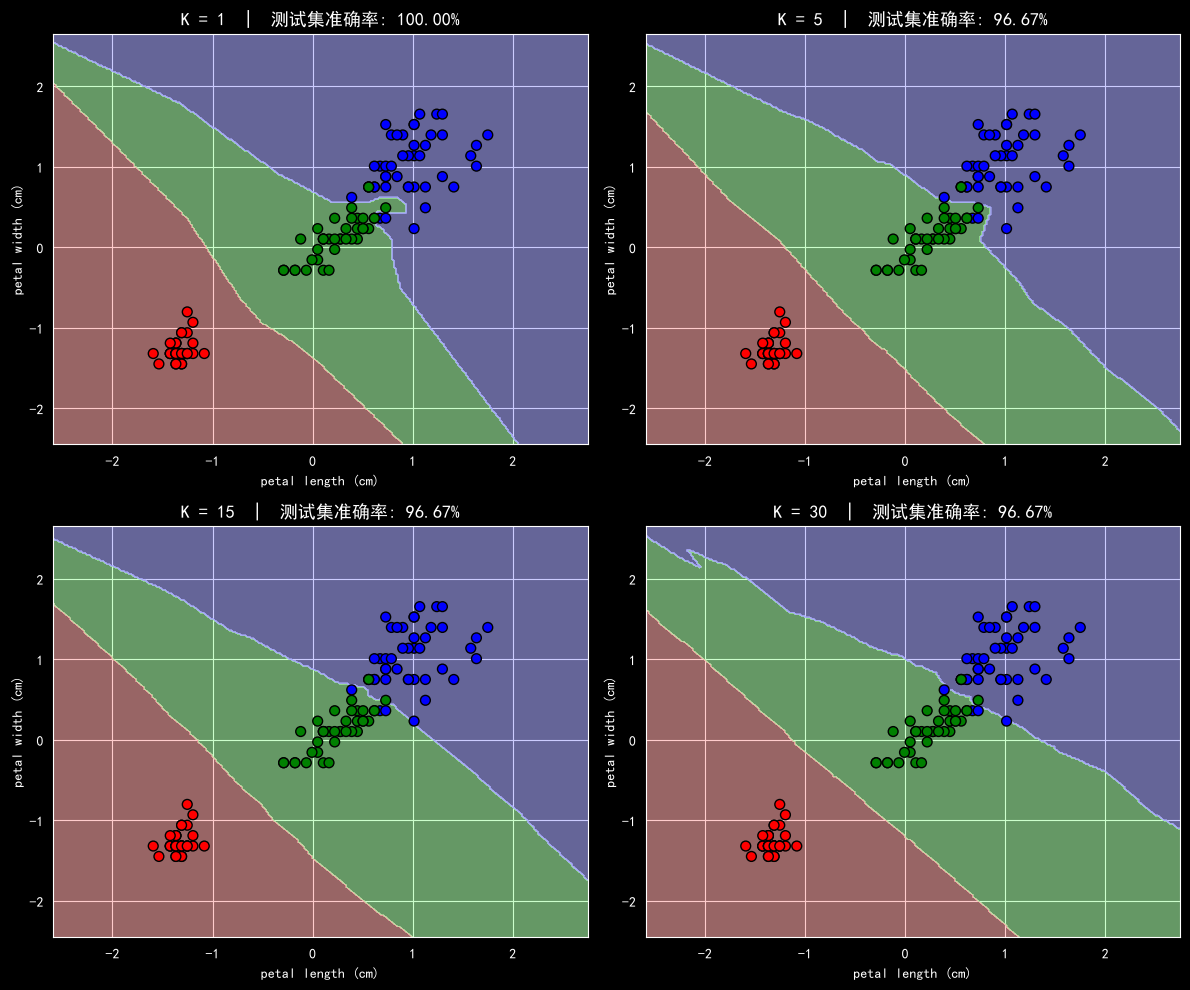

In [120]:
"""关于绘图部分的代码基本可以套用，只需要改几个关键的参量就行"""

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 取后两个特征（区分度最高），重新训练 + 标准化
feature_idx = [2, 3]  # petal length, petal width
X_2d = iris.data[:, feature_idx]

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size = 0.2, random_state = 1
)

scaler_2d = StandardScaler()
X_train_2d = scaler_2d.fit_transform(X_train_2d)
X_test_2d = scaler_2d.transform(X_test_2d)

# 创建网格
h = 0.02  # 网格步长，步长越小，采样点越多，图像越平滑但绘制越慢
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 用不同 K 值画子图对比
k_values = [1, 5, 15, 30]
fig, axes = plt.subplots(2, 2, figsize = (12, 10))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold  = ['red', 'green', 'blue']

for ax, k in zip(axes.flat, k_values):
    knn_2d = KNeighborsClassifier(n_neighbors = k)
    knn_2d.fit(X_train_2d, y_train_2d)

    # 预测网格上每个点的类别，画决策背景
    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap = cmap_light, alpha = 0.6)

    # 叠上训练点
    scatter = ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                         c = y_train_2d, cmap = ListedColormap(cmap_bold),
                         edgecolor = 'k', s = 50)

    acc = knn_2d.score(X_test_2d, y_test_2d)
    ax.set_title(f'K = {k}  |  测试集准确率: {acc:.2%}', fontsize=13)
    ax.set_xlabel(iris.feature_names[feature_idx[0]])
    ax.set_ylabel(iris.feature_names[feature_idx[1]])

plt.tight_layout()
plt.show()

---
最后来总结一下关于 KNN 的几个需要注意的问题：
- 计算量大：每次预测都要遍历所有训练数据，样本多了会慢，此时也就不适合需要实时计算的场景了。
- 维度灾难：特征太多时，距离会变得不那么“有意义”，而且计算量指数级增长。所以高维数据需要先降维或选出主要特征。
- 数据预处理的强制要求：标准化/归一化，不然某些特征一骑绝尘，直接把距离带偏了。
- 类别不平衡：如果某个类样本非常多，投票时容易“压死”少数类，此时就更适合用距离加权投票。